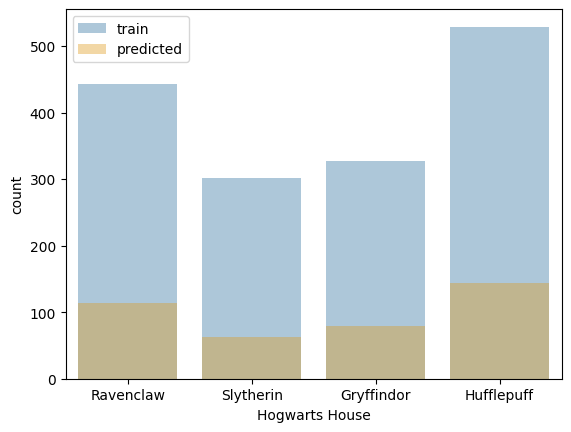

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TRAIN_DATASET_PATH = "../datasets/dataset_train.csv"

data= pd.read_csv(TRAIN_DATASET_PATH)
y_pred = pd.read_csv("../houses.csv")

target="Hogwarts House"

labels = data[target].unique().tolist()

# X = train[""]

fig, ax = plt.subplots()

sns.countplot(x=target, data=data, alpha=0.4,ax=ax)
sns.countplot(x=target, data=y_pred, alpha=0.4, color="orange",ax=ax)
plt.legend(["train", "predicted"])
plt.show()

/tmp/ipykernel_362746/804366592.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


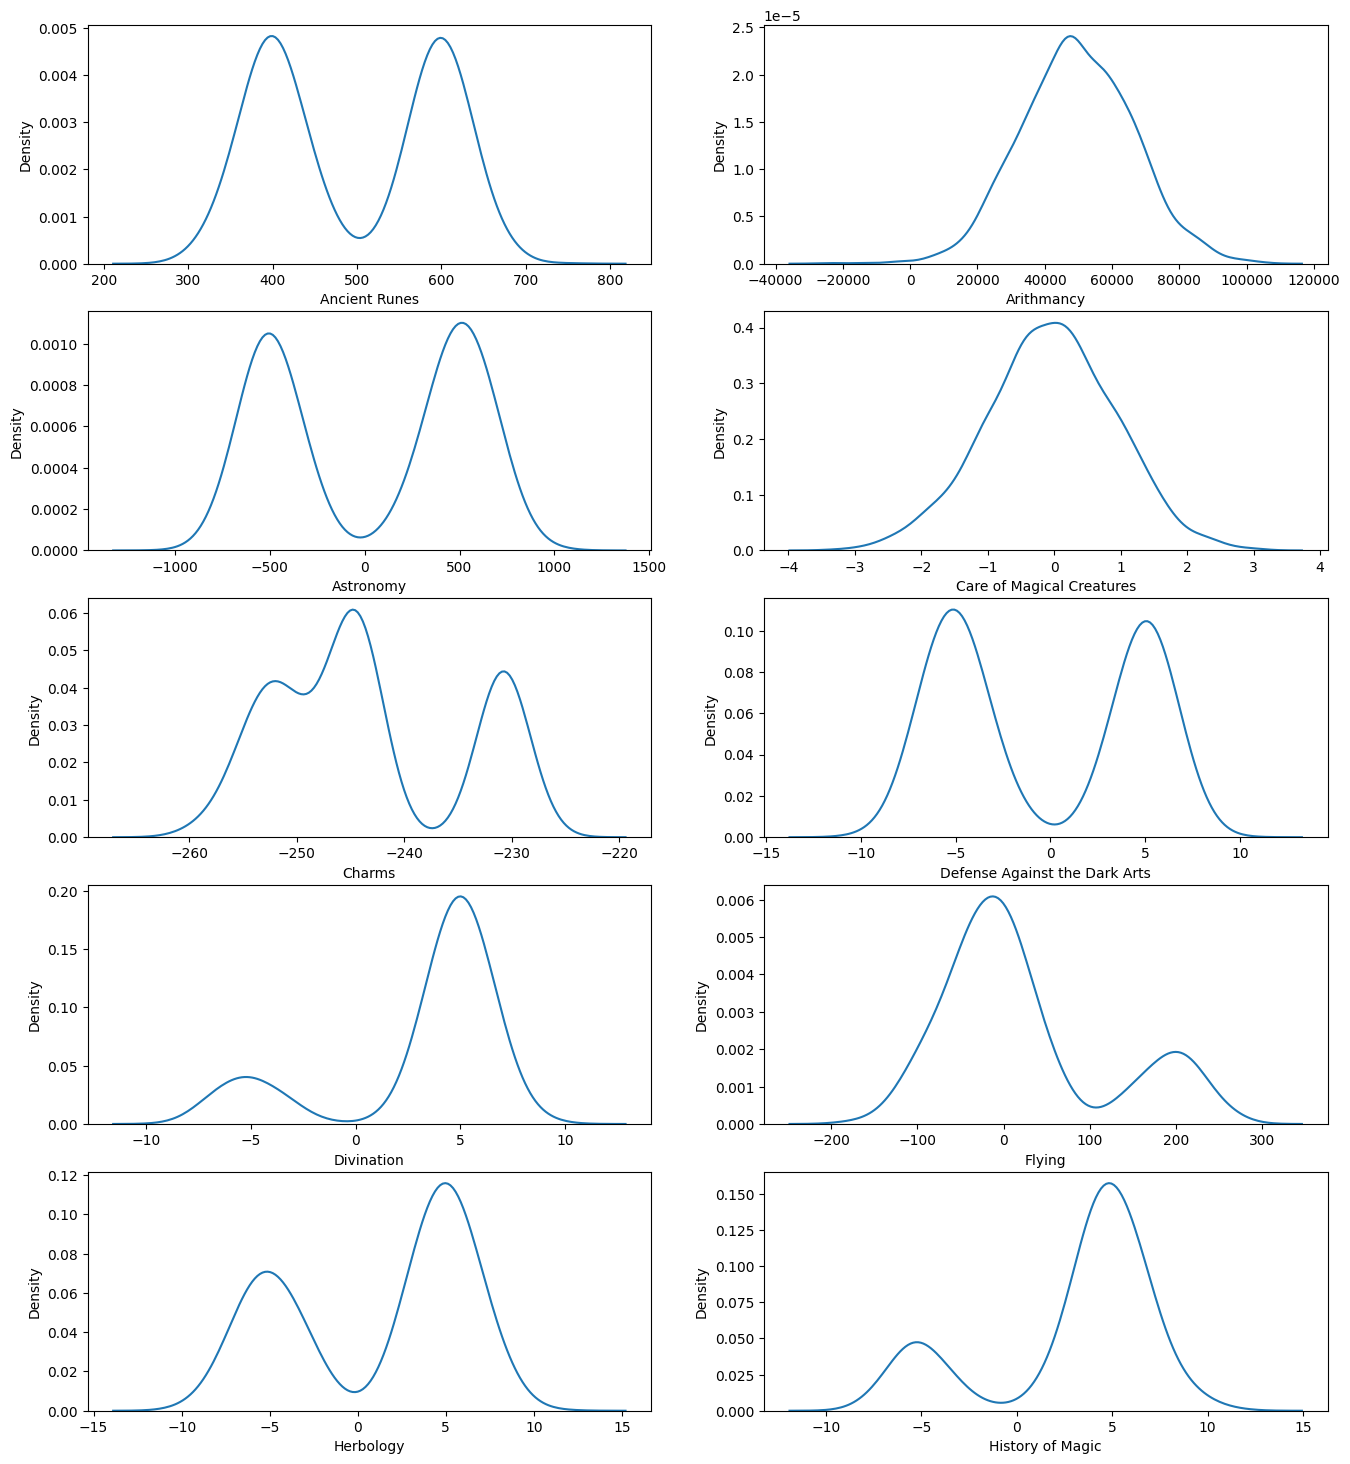

In [43]:
cols_to_drop = ["Index", "First Name", "Last Name", "Birthday"]
data = data[data.columns.difference(cols_to_drop).tolist()]  # type: ignore

categorical_features = ["Best Hand"]
num_features = data.columns.difference(categorical_features).tolist() # type: ignore

fig, axes = plt.subplots(5,2, figsize=(16,18))
for ax, col in zip(axes.flat, num_features):
    sns.kdeplot(data=data[col],ax=ax) # type: ignore


fig.show()

In [44]:
from sklearn.model_selection import train_test_split
import joblib

y = data[target]
data = data.drop(columns=target)
X_train, X_valid, y_train, y_valid = train_test_split(data, y, stratify=y, test_size=0.2)



In [45]:
from logreg_train import preprocess
from sklearn.preprocessing import LabelEncoder

X_train_proc, y_train_proc, preprocessor = preprocess(X_train, y_train)

X_valid_proc = preprocessor.transform(X_valid)

le = LabelEncoder()

# shouldnt fit_transform, should only transform and use the same label encoder as X.
# did it for simplicity, values are the same
y_valid_proc = le.fit_transform(y_valid)

In [46]:
from ft_logistic_regression import FtLogisticRegression as LogisticRegression
# from sklearn.linear_model import LogisticRegression

# clf = LogisticRegression()
# clf = LogisticRegression(solver="sgd")
clf = LogisticRegression(solver="mbgd", max_iter=100)

clf.fit(X_train_proc, y_train_proc)

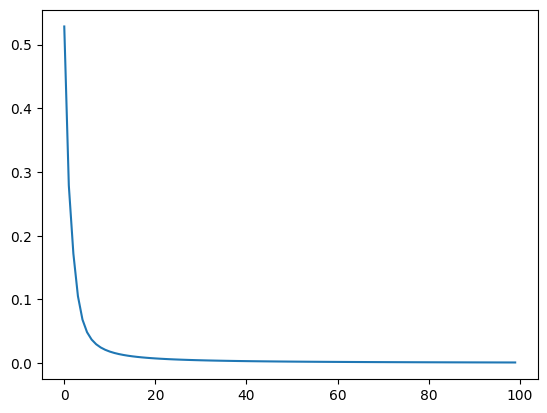

In [47]:
y_pred = clf.predict(X_valid_proc)

plt.plot(clf.loss_)

              precision    recall  f1-score   support

  Gryffindor       1.00      0.98      0.99        65
  Hufflepuff       0.97      1.00      0.99       106
   Ravenclaw       0.97      0.99      0.98        89
   Slytherin       0.98      0.92      0.95        60

    accuracy                           0.98       320
   macro avg       0.98      0.97      0.98       320
weighted avg       0.98      0.98      0.98       320



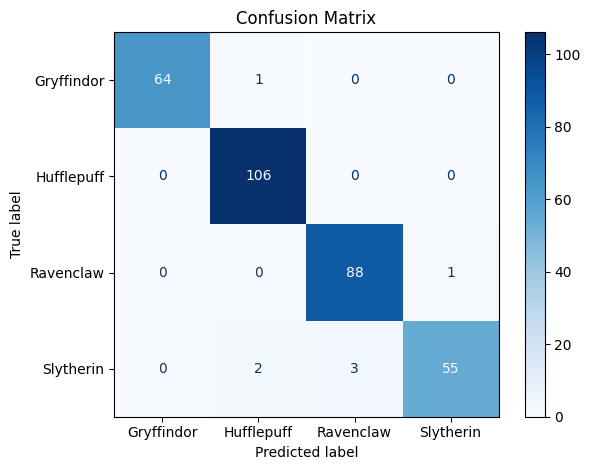

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_valid_proc_decoded = le.inverse_transform(y_valid_proc)
y_pred_decoded = le.inverse_transform(y_pred)

print(classification_report(y_pred=y_pred_decoded, y_true=y_valid_proc_decoded))



cm = confusion_matrix(y_valid_proc_decoded, y_pred_decoded)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

Text(0.5, 1.0, 'PR curve')

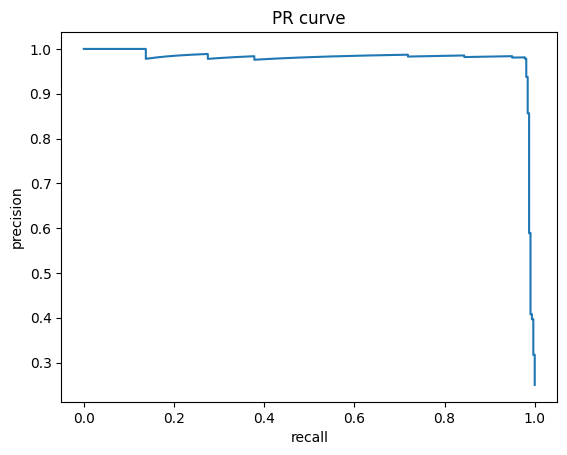

In [49]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

class_indices = le.classes_

proba = clf.predict_proba(X_valid_proc)
y_valid_bin = label_binarize(y_valid_proc, classes=range(len(class_indices)))


precision, recall, _ = precision_recall_curve(y_valid_bin.ravel(), proba.ravel())


plt.plot(recall, precision)

plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR curve")






In [50]:
# explainability

import shap



features = preprocessor.get_feature_names_out()
features = [f.strip("num__") for f in features]


X_train_df = pd.DataFrame(X_train_proc, columns=features)
X_valid_df = pd.DataFrame(X_valid_proc, columns=features)



masker = shap.maskers.Independent(X_train_df, max_samples=len(X_train_df))

explainer = shap.LinearExplainer(clf, masker=masker)



shap_values = explainer.shap_values(X_valid_df)

fig, axes = plt.subplots(len(le.classes_), figsize=(20, 6))

for i, cl in enumerate(le.classes_):
    plt.sca(axes[i])
    shap.summary_plot(shap_values[:,:,i], X_valid_df, title=cl, show=False, plot_size=(10,30))
    plt.title(cl)

plt.show()

InvalidModelError: An unknown model type was passed: <class 'ft_logistic_regression.FtLogisticRegression'>